In [23]:
import sys
print(sys.executable)

c:\Users\adity\CustomerChurn\Customer-Churn\venv\Scripts\python.exe


In [24]:
import pandas as pd
import numpy as np
import sklearn
import xgboost

print("Environment Ok")


Environment Ok


In [25]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [27]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [28]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [29]:
df["TotalCharges"].dtype
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [30]:
df = df.dropna()
print(df.shape)

(7032, 21)


In [31]:
df.to_csv("../data/telco_churn_cleaned.csv", index=False)
import os

os.path.exists("../data/telco_churn_cleaned.csv")

True

In [32]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


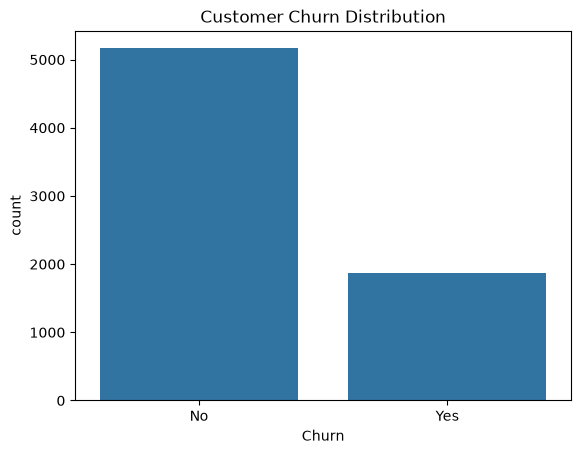

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.countplot(data = df, x = "Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [34]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


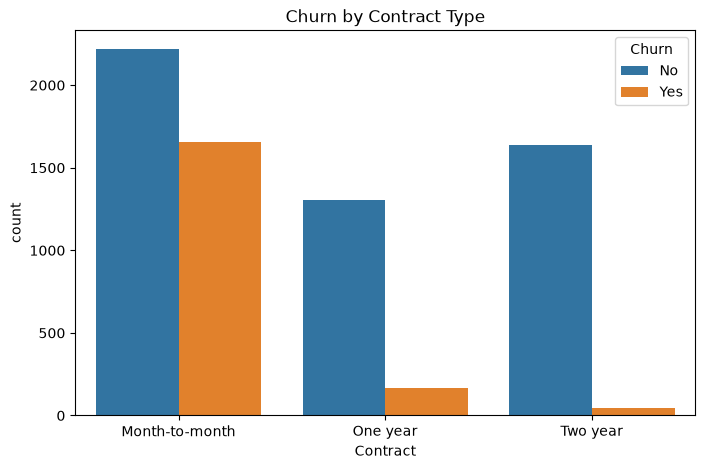

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.show()

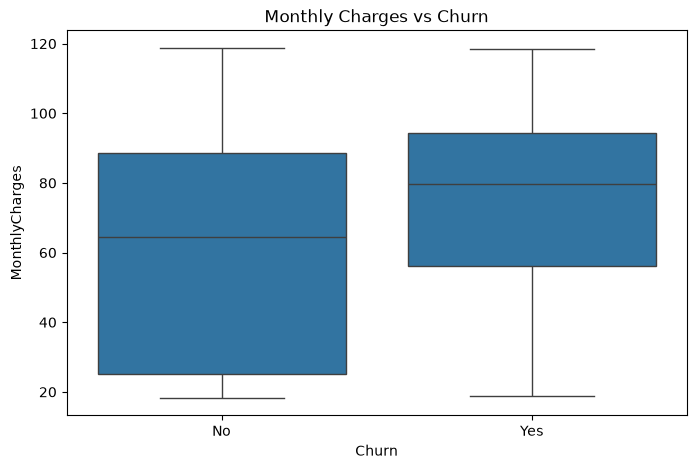

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [37]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [38]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

# Key Business Insights

1. Overall churn rate is 26.58%.

2. Month-to-month customers churn at 42.7%, compared to only 2.8% for two-year contracts.

3. Customers who churn pay higher monthly charges on average ($74.44 vs $61.31).

4. Churned customers have much lower tenure (17.98 months) than retained customers (37.65 months).

Conclusion:
Contract type, tenure, and monthly charges appear to be strong churn predictors.

In [40]:
df_model = df.copy()
df_model = df_model.drop("customerID", axis=1)
df_model.shape


(7032, 20)

In [41]:
df_model["Churn"] = df_model["Churn"].map({ #converted churn to 0 and 1 for model building
    "No": 0,
    "Yes": 1
})
df_model["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [42]:
categorical_cols = df_model.select_dtypes(include="object").columns

print(categorical_cols)
print(f"\nTotal categorical columns: {len(categorical_cols)}")

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Total categorical columns: 15


C:\Users\adity\AppData\Local\Temp\ipykernel_12552\2302895783.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include="object").columns


In [43]:
df_encoded = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype=int
)
print(df_encoded.shape)

(7032, 31)


In [47]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [49]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7711442786069652
Precision: 0.5760233918128655
recall   : 0.5267379679144385
F1 Score : 0.5502793296089385
ROC-AUC  : 0.8113899084231069


In [51]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.446928
25,Contract_Two year,0.139514
11,InternetService_No,0.092819
24,Contract_One year,0.087552
1,tenure,0.023261
23,StreamingMovies_Yes,0.020556
9,MultipleLines_Yes,0.015032
28,PaymentMethod_Electronic check,0.014753
13,OnlineSecurity_Yes,0.013672
15,OnlineBackup_Yes,0.013632


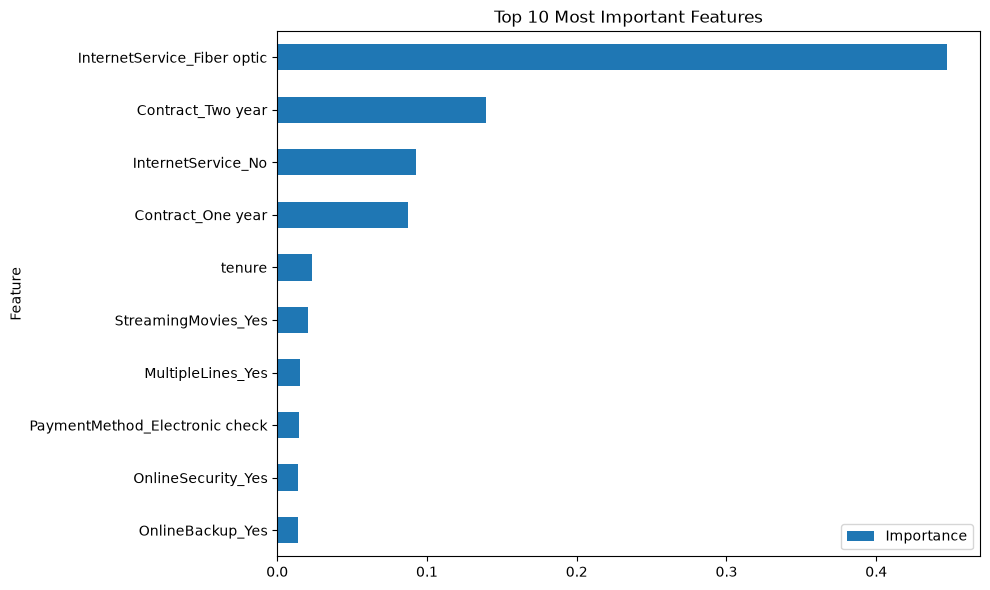

In [52]:
import matplotlib.pyplot as plt

feature_importance.head(10).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Most Important Features")
plt.tight_layout()
plt.show()